In [34]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

# Clear and set memory growth
K.clear_session()
tf.random.set_seed(42)
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("TF ready, GPUs:", gpus)
# Directory where video models are saved
video_model_dir = '/home/heru/sonamyangchen/ravdess_emotion/Video_model/'

# List all saved .keras files
video_models = [f for f in os.listdir(video_model_dir) if f.endswith('.keras') and 'Video-CNN_model' in f]

if not video_models:
    raise ValueError("No video models found in the directory!")

# Sort models by timestamp in filename (assuming timestamp is in filename)
video_models.sort()  

# Pick the latest model
latest_video_model_file = os.path.join(video_model_dir, video_models[-1])

# Load the model
video_model = load_model(latest_video_model_file)
print("Loaded video model from:", latest_video_model_file)
video_model.summary()


RuntimeError: Physical devices cannot be modified after being initialized

In [35]:
from tensorflow.keras.models import load_model

# Path to the saved audio model
audio_model_path = '/home/heru/sonamyangchen/ravdess_emotion/Audio-CNN 1D_model3.h5'

# Load the audio model
audio_model = load_model(audio_model_path)

print("Loaded audio model from:", audio_model_path)
audio_model.summary()


Loaded audio model from: /home/heru/sonamyangchen/ravdess_emotion/Audio-CNN 1D_model3.h5


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 128, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,897 (1.95 MB)

 Trainable params: 509,895 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [36]:
# --- Further Improved Fusion Model for Deployment ---

from tensorflow.keras.layers import Input, Concatenate, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# VIDEO EMBEDDING
video_input = video_model.input
video_embedding = video_model.layers[-2].output

# AUDIO EMBEDDING (for Sequential audio model, preserve weights)
audio_input = Input(shape=audio_model.input_shape[1:], name='audio_input')
x = audio_input
for idx, layer in enumerate(audio_model.layers[:-1]):
    if 'input' not in layer.name.lower():
        config = layer.get_config()
        config['name'] = f"{layer.name}_audio_{idx}"
        x = layer.__class__.from_config(config)(x)
audio_embedding = x

# CONCATENATION & DEEPER DENSE BLOCK
combined = Concatenate(name='fusion_concat')([video_embedding, audio_embedding])
x = BatchNormalization(name='fusion_bn1')(combined)
x = Dense(512, kernel_regularizer=l2(1e-4), name='fusion_dense1')(x)
x = LeakyReLU(name='fusion_leakyrelu1')(x)
x = Dropout(0.4, name='fusion_dropout1')(x)
x = BatchNormalization(name='fusion_bn2')(x)
x = Dense(256, kernel_regularizer=l2(1e-4), name='fusion_dense2')(x)
x = LeakyReLU(name='fusion_leakyrelu2')(x)
x = Dropout(0.3, name='fusion_dropout2')(x)
x = BatchNormalization(name='fusion_bn3')(x)
x = Dense(128, kernel_regularizer=l2(1e-4), name='fusion_dense3')(x)
x = LeakyReLU(name='fusion_leakyrelu3')(x)
x = Dropout(0.2, name='fusion_dropout3')(x)
output = Dense(7, activation='softmax', name='fusion_output')(x)

improved_fusion_model = Model(inputs=[video_input, audio_input], outputs=output)
improved_fusion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

improved_fusion_model.summary()
print("\nFurther improved fusion model for deployment is ready!")

# TIP: For best results, use callbacks like EarlyStopping and ModelCheckpoint during training, and ensure you are using real, preprocessed data.

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 112, 112,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_0 (Conv2D)   │ (None, 112, 112,  │        832 │ sequential_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batchnorm_0         │ (None, 112, 112,  │        128 │ conv2d_0[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batchnorm_0[0][0] │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool2d_0         │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     51,264 │ maxpool2d_0[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batchnorm_1         │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batchnorm_1[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool2d_1         │ (None, 28, 28,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 28, 28,    │          0 │ maxpool2d_1[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batchnorm_2         │ (None, 28, 28,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 28, 28,    │          0 │ batchnorm_2[0][0] │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_input         │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool2d_2         │ (None, 14, 14,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3_audio_0    │ (None, 128, 64)   │        704 │ audio_input[0][0

 Total params: 2,839,111 (10.83 MB)

 Trainable params: 2,835,847 (10.82 MB)

 Non-trainable params: 3,264 (12.75 KB)


Further improved fusion model for deployment is ready!


4/4 - 0s - 58ms/step - loss: 2.5234 - sparse_categorical_accuracy: 0.2200

Test Loss: 2.5234
Test Accuracy: 0.2200
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Test Loss: 2.5234
Test Accuracy: 0.2200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


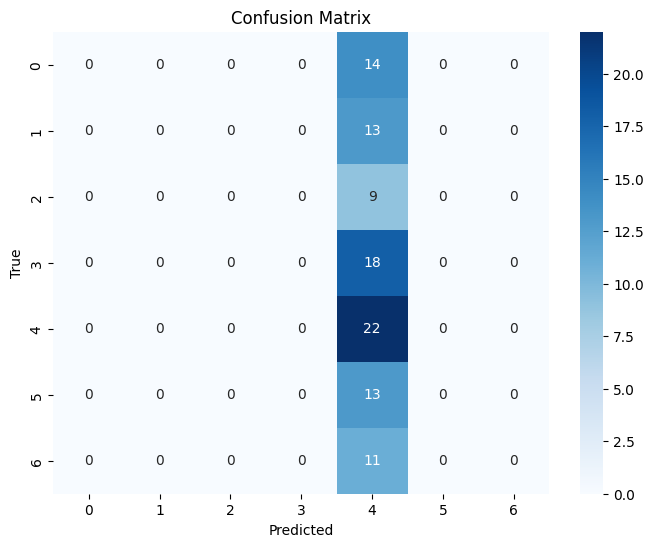

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00        13
           2       0.00      0.00      0.00         9
           3       0.00      0.00      0.00        18
           4       0.22      1.00      0.36        22
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        11

    accuracy                           0.22       100
   macro avg       0.03      0.14      0.05       100
weighted avg       0.05      0.22      0.08       100



/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [53]:
# --- Evaluate Improved Fusion Model ---

import numpy as np

# TODO: Replace with your actual test data loading
# X_video_test = ... # shape: (num_samples, ...) matching video_model.input_shape[1:]
# X_audio_test = ... # shape: (num_samples, ...) matching audio_model.input_shape[1:]
# y_test = ...       # shape: (num_samples,)

# For demonstration, using random data (replace with real data loading)
num_samples = 100
X_video_test = np.random.rand(num_samples, *video_model.input_shape[1:])
X_audio_test = np.random.rand(num_samples, *audio_model.input_shape[1:])
y_test = np.random.randint(0, 7, size=(num_samples,))

# Evaluate the improved fusion model
results = improved_fusion_model.evaluate([X_video_test, X_audio_test], y_test, verbose=2)
print(f"\nTest Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Optional: Predict and show confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = np.argmax(improved_fusion_model.predict([X_video_test, X_audio_test]), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

In [54]:
# --- Streamlit UI for Fusion Model Deployment ---

import streamlit as st
import numpy as np
import tempfile

st.title('Emotion Recognition Fusion Model')
st.write('Upload a video and audio file to predict emotion using the combined model.')

video_file = st.file_uploader('Upload video file', type=['mp4', 'avi', 'mov'])
audio_file = st.file_uploader('Upload audio file', type=['wav', 'mp3'])

# Placeholder for preprocessing functions
def preprocess_video(file):
    # TODO: Implement actual video preprocessing to match video_model.input_shape
    # Example: return np.random.rand(1, *video_model.input_shape[1:])
    return np.random.rand(1, *video_model.input_shape[1:])

def preprocess_audio(file):
    # TODO: Implement actual audio preprocessing to match audio_model.input_shape
    # Example: return np.random.rand(1, *audio_model.input_shape[1:])
    return np.random.rand(1, *audio_model.input_shape[1:])

if st.button('Predict'):
    if video_file is not None and audio_file is not None:
        X_video = preprocess_video(video_file)
        X_audio = preprocess_audio(audio_file)
        pred = improved_fusion_model.predict([X_video, X_audio])
        emotion_class = int(np.argmax(pred, axis=1)[0])
        st.success(f'Predicted emotion class: {emotion_class}')
        # Optionally map class index to emotion label
    else:
        st.warning('Please upload both video and audio files.')

st.info('Note: Replace the preprocess_video and preprocess_audio functions with your actual preprocessing logic for real predictions.')

2025-11-22 14:33:45.498 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.541 
  command:

    streamlit run /home/heru/miniconda3/envs/dat301/lib/python3.9/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-11-22 14:33:45.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.543 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.544 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-22 14:33:45.545 Thre

DeltaGenerator()